In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
plt.rcParams.update({'font.size': 14,
                     'axes.titlepad': 10,
                     'axes.titlesize': 16,
                     'axes.labelsize': 14,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })

    Unnamed: 0     T    y0 network_architectures activations  learning_rates  \
0            0  10.0  0.01               (4, 50)       swish           0.001   
2            0  10.0  0.10               (4, 50)       swish           0.001   
4            0  10.0  0.50               (4, 50)       swish           0.001   
6            0  12.5  0.01               (4, 50)       swish           0.001   
8            0  12.5  0.10               (4, 50)       swish           0.001   
10           0  12.5  0.50               (4, 50)       swish           0.001   
12           0  15.0  0.01               (4, 50)       swish           0.001   
14           0  15.0  0.10               (4, 50)       swish           0.001   
16           0  15.0  0.50               (4, 50)       swish           0.001   

    collocations  epochs regularization  reg_epochs  reg_coeff reg_decay  \
0           1024   25000         no_reg         0.5        1.0    linear   
2           1024   25000         no_reg        

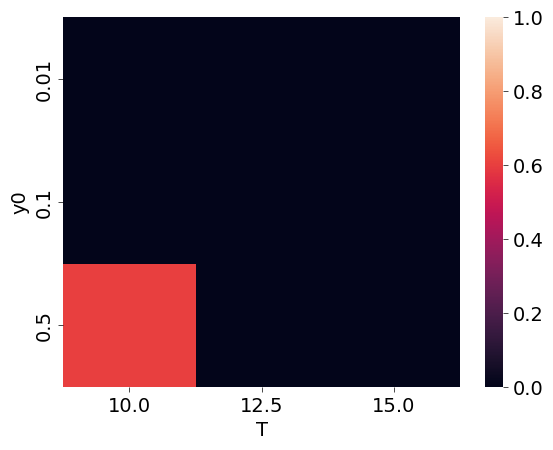

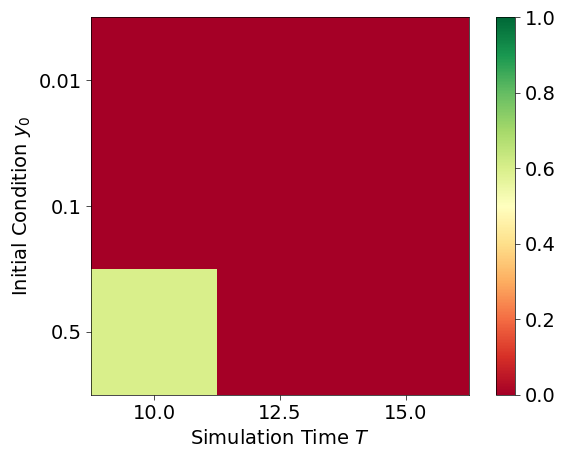

    Unnamed: 0     T    y0 network_architectures activations  learning_rates  \
1            0  10.0  0.01               (4, 50)       swish           0.001   
3            0  10.0  0.10               (4, 50)       swish           0.001   
5            0  10.0  0.50               (4, 50)       swish           0.001   
7            0  12.5  0.01               (4, 50)       swish           0.001   
9            0  12.5  0.10               (4, 50)       swish           0.001   
11           0  12.5  0.50               (4, 50)       swish           0.001   
13           0  15.0  0.01               (4, 50)       swish           0.001   
15           0  15.0  0.10               (4, 50)       swish           0.001   
17           0  15.0  0.50               (4, 50)       swish           0.001   

    collocations  epochs              regularization  reg_epochs  reg_coeff  \
1           1024   25000  reg_derivative_unstable_fp         0.5        1.0   
3           1024   25000  reg_derivative_

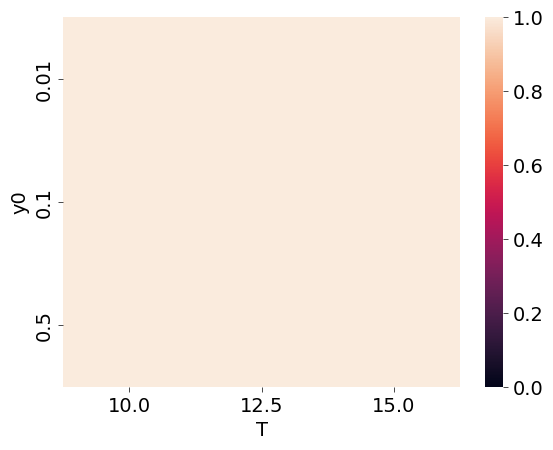

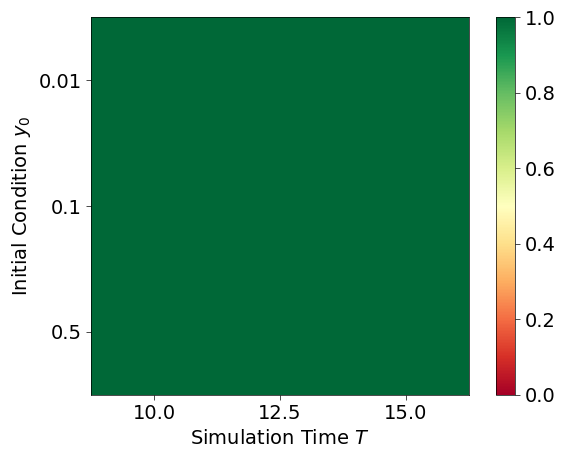

In [13]:
results = pd.read_csv("results_paper/results_new_full.csv")

for reg in results["regularization"].unique():
    results_subset = results.loc[results["regularization"] == reg]
    print(results_subset)
    table = pd.pivot_table(results_subset, values="loss_successes_percent", 
                        index=["y0"],
                        columns=["T"],
                        aggfunc="mean")
    
    table.to_csv(f"grid_{reg}_results.csv")
    
    sns.heatmap(table, vmin=0, vmax=1.0)
    plt.show()

    fig, ax = plt.subplots()

    ims = ax.imshow(table, cmap='RdYlGn',vmin=0,  vmax=1.0)
    fig.colorbar(ims)

    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels(table.columns)
    ax.set_xlabel(r'Simulation Time $T$')

    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_ylabel(r'Initial Condition $y_0$')


    plt.tight_layout()
    plt.show()

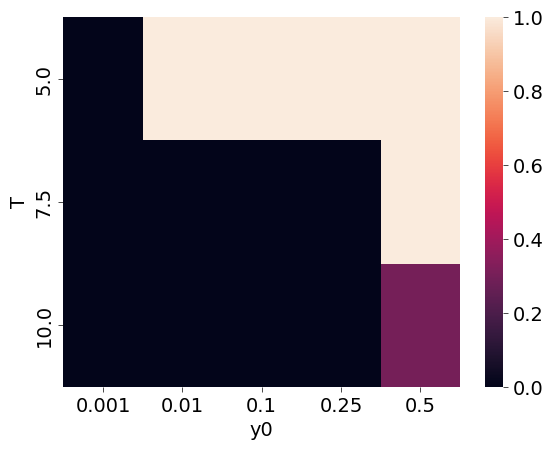

In [3]:
results = pd.read_csv("results_no_reg.csv")

table = pd.pivot_table(results, values="loss_successes_percent", 
                        index=["T"],
                        columns=["y0"],
                        aggfunc="mean")
sns.heatmap(table)
plt.show()

T      1    2    3    4    5     6    7     8     9     10
y0                                                        
0.05  1.0  1.0  1.0  1.0  1.0  0.85  0.0  0.00  0.00  0.00
0.15  1.0  1.0  1.0  1.0  1.0  0.95  0.0  0.00  0.00  0.00
0.25  1.0  1.0  1.0  1.0  1.0  1.00  0.0  0.00  0.00  0.00
0.35  1.0  1.0  1.0  1.0  1.0  1.00  0.0  0.00  0.00  0.00
0.45  1.0  1.0  1.0  1.0  1.0  1.00  0.2  0.35  0.25  0.10
0.55  1.0  1.0  1.0  1.0  1.0  1.00  1.0  0.95  0.95  0.85
0.65  1.0  1.0  1.0  1.0  1.0  1.00  1.0  1.00  1.00  1.00
0.75  1.0  1.0  1.0  1.0  1.0  1.00  1.0  1.00  1.00  1.00
0.85  1.0  1.0  1.0  1.0  1.0  1.00  1.0  1.00  1.00  1.00
0.95  1.0  1.0  1.0  1.0  1.0  1.00  1.0  1.00  1.00  1.00


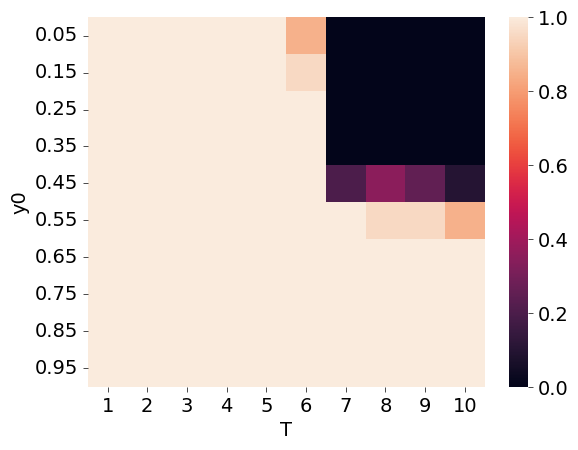

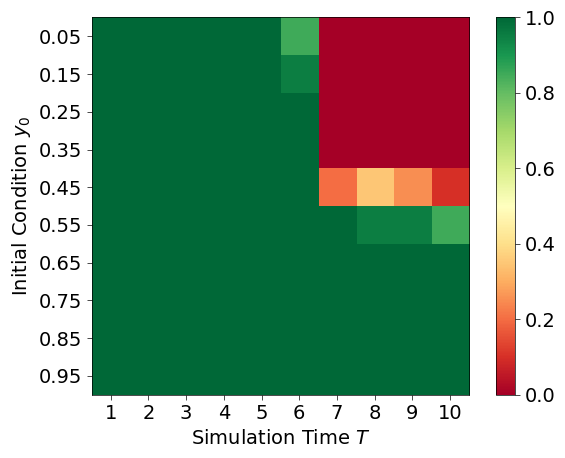

In [4]:
import os 
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

table_list = []
for filename in os.listdir("vanilla_PINN"):
    data = pd.read_csv(f"vanilla_PINN/{filename}")
    table_list.append(data)

table = pd.concat(table_list)

table = pd.pivot_table(table, values="loss_successes_percent", index="y0", columns="T")
table.to_csv("no_reg_results_full.csv")
print(table)
sns.heatmap(table)
plt.show()

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn')
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $y_0$')


plt.tight_layout()
plt.show()

T-y0 7.5-0.001,
regularizing stability


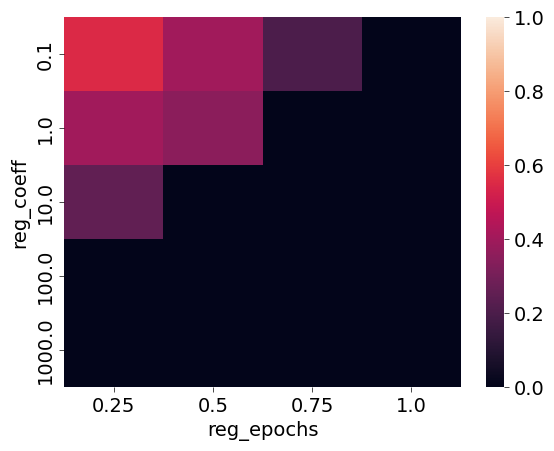

T-y0 7.5-0.001,
 regularizing distance to fixed point


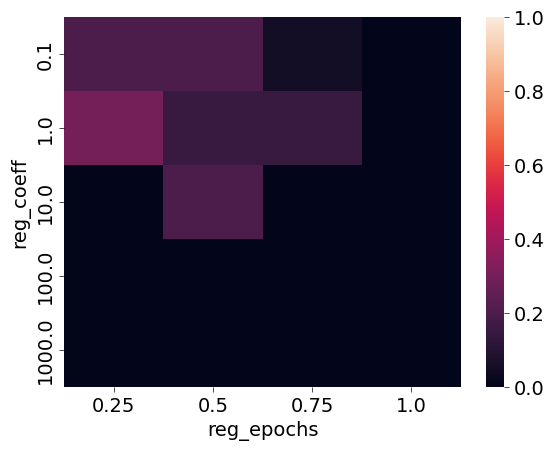

T-y0 7.5-0.001,
regularizing stability around the fixed point


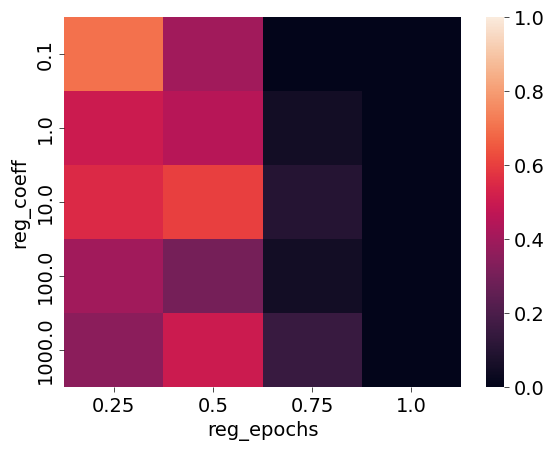

T-y0 7.5-0.01,
regularizing stability


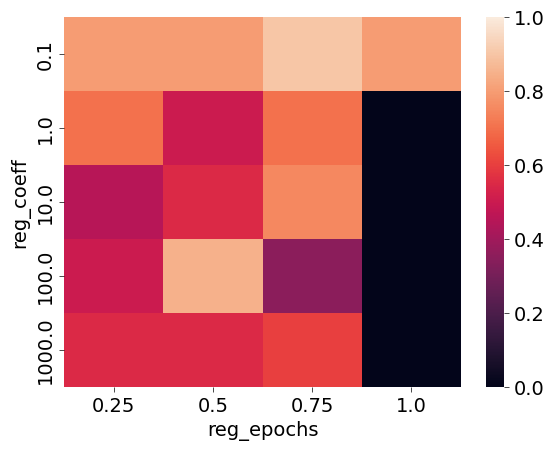

T-y0 7.5-0.01,
 regularizing distance to fixed point


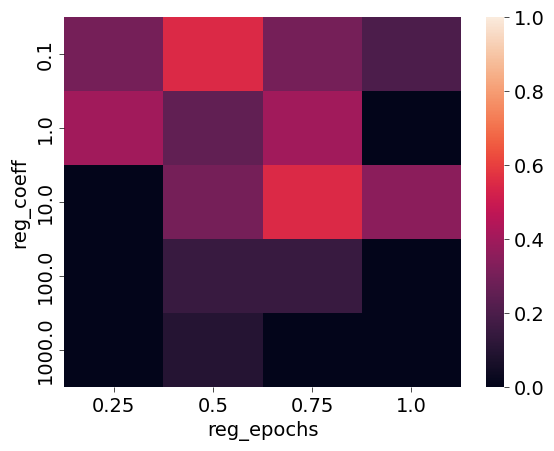

T-y0 7.5-0.01,
regularizing stability around the fixed point


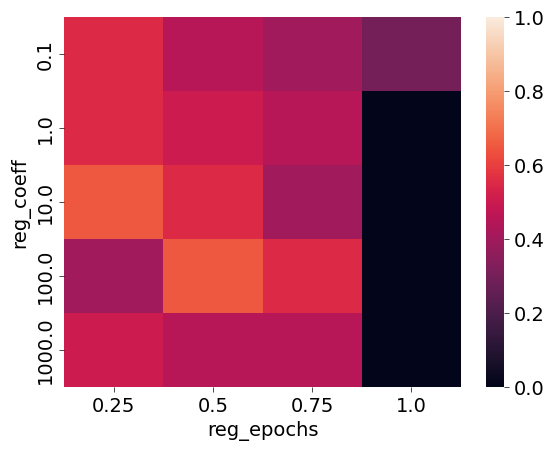

T-y0 7.5-0.1,
regularizing stability


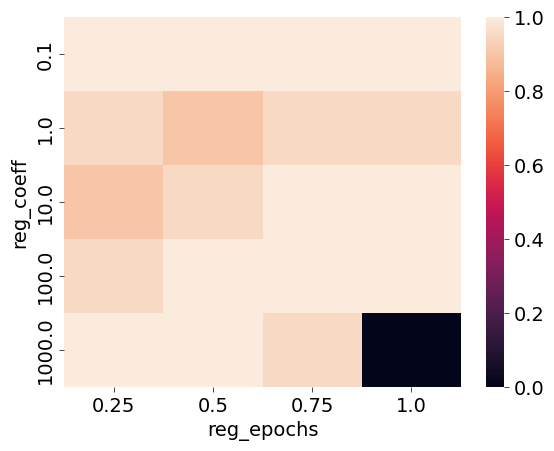

T-y0 7.5-0.1,
 regularizing distance to fixed point


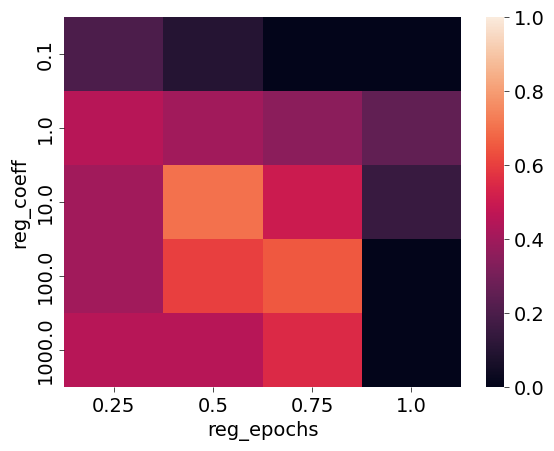

T-y0 7.5-0.1,
regularizing stability around the fixed point


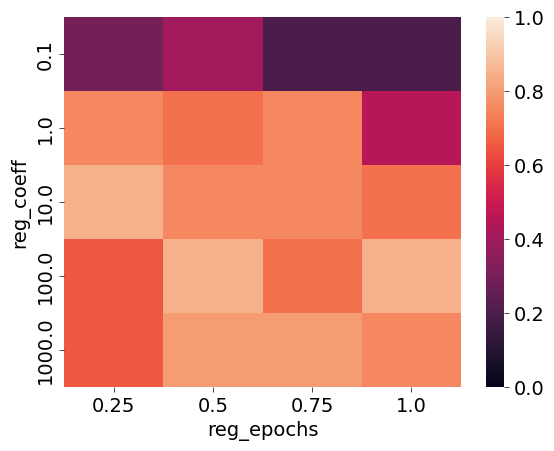

T-y0 10.0-0.001,
regularizing stability


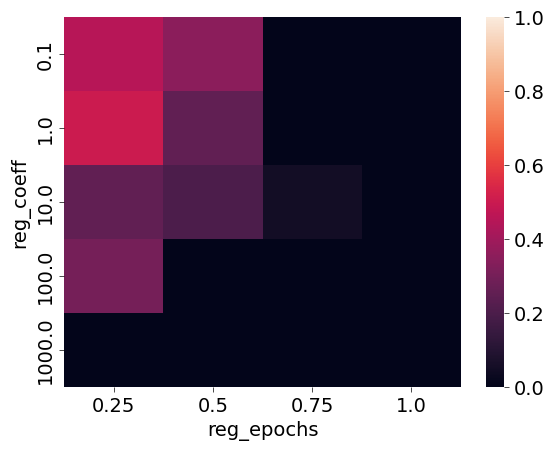

T-y0 10.0-0.001,
 regularizing distance to fixed point


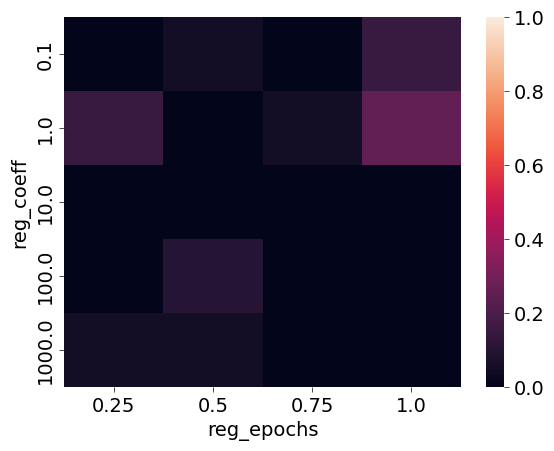

T-y0 10.0-0.001,
regularizing stability around the fixed point


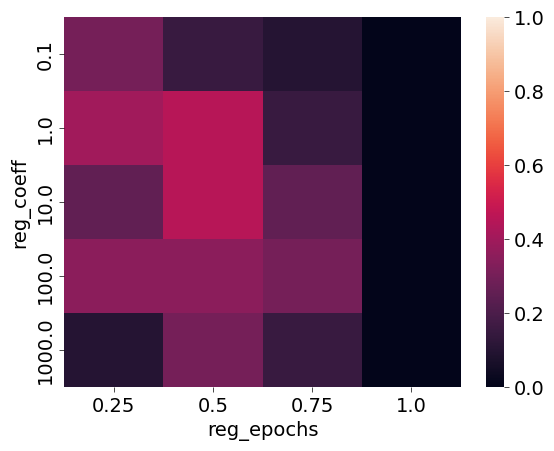

T-y0 10.0-0.01,
regularizing stability


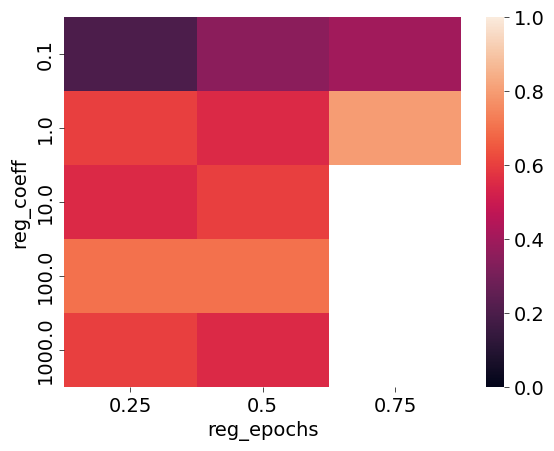

T-y0 10.0-0.01,
 regularizing distance to fixed point


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


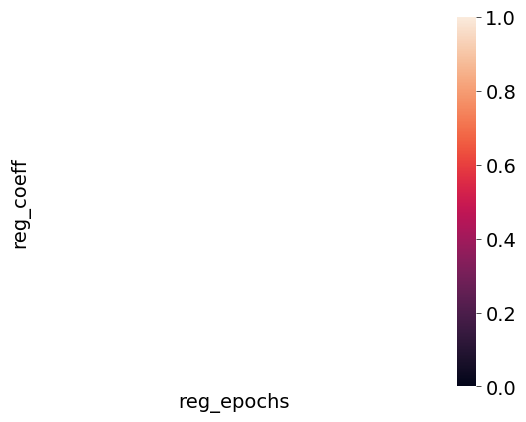

T-y0 10.0-0.01,
regularizing stability around the fixed point


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


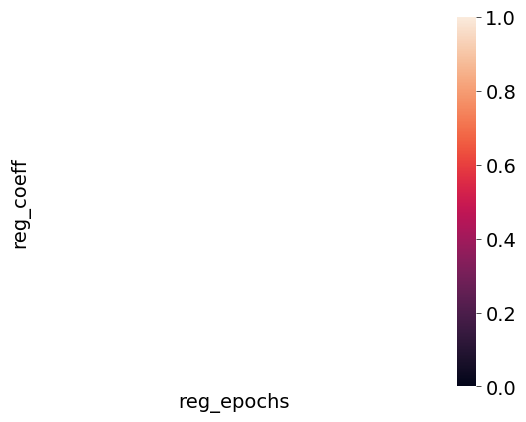

In [5]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}

results = pd.read_csv("results_linear_decay.csv")

results["T-y0"] = results["T"].astype(str) + "-" + results["y0"].astype(str)

dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)

for settings in results["T-y0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-y0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")

        table.to_csv(f"{dirname}/results_{regularization}_settingsT-y0_{settings}.csv")

        sns.heatmap(table, vmin=0, vmax=1.0)
        #plt.title(f"T-y0 {settings},\n{regularization_names[regularization]}")
        print(f"T-y0 {settings},\n{regularization_names[regularization]}")
        plt.savefig(f"{dirname}/results_{regularization}_settingsT-y0_{settings}.png")
        plt.show()
        

T      1    2    3    4    5     6     7     8     9     10
y0                                                         
0.05  1.0  1.0  1.0  1.0  1.0  0.95  0.40  0.45  0.40  0.15
0.15  1.0  1.0  1.0  1.0  1.0  1.00  0.75  0.50  0.40  0.30
0.25  1.0  1.0  1.0  1.0  1.0  1.00  0.85  0.40  0.25  0.15
0.35  1.0  1.0  1.0  1.0  1.0  1.00  0.90  0.30  0.25  0.25
0.45  1.0  1.0  1.0  1.0  1.0  1.00  0.95  0.55  0.35  0.30
0.55  1.0  1.0  1.0  1.0  1.0  1.00  1.00  0.70  0.25  0.55
0.65  1.0  1.0  1.0  1.0  1.0  1.00  0.95  0.70  0.55  0.60
0.75  1.0  1.0  1.0  1.0  1.0  1.00  1.00  0.75  0.80  0.75
0.85  1.0  1.0  1.0  1.0  1.0  1.00  1.00  0.80  1.00  0.75
0.95  1.0  1.0  1.0  1.0  1.0  1.00  1.00  0.95  0.85  0.90


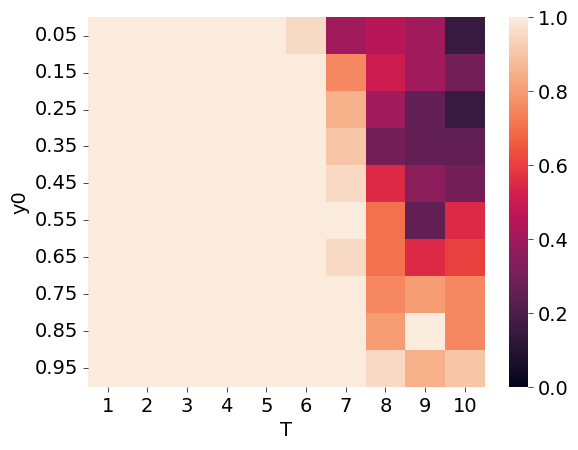

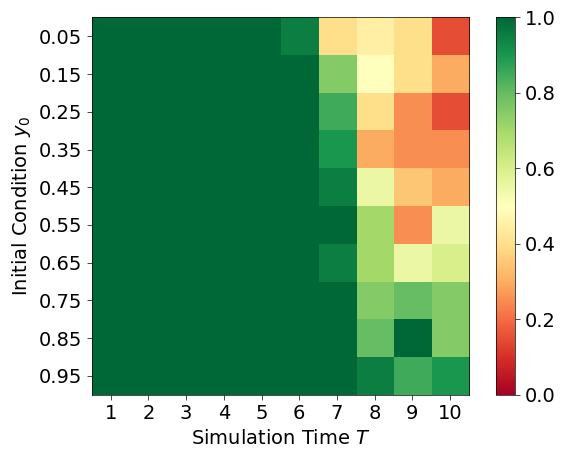

In [6]:
import os 
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

table_list = []
for filename in os.listdir("regularized_PINN/reg_derivative"):
    data = pd.read_csv(f"regularized_PINN/reg_derivative/{filename}")
    table_list.append(data)

table = pd.concat(table_list)

table = pd.pivot_table(table, values="loss_successes_percent", index="y0", columns="T")
table.to_csv("regularized_results_full.csv")
print(table)
sns.heatmap(table, vmin=0, vmax=1)
plt.show()

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn', vmin=0, vmax=1)
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $y_0$')


plt.tight_layout()
plt.show()